# Hourly Shift Grid Search

This notebook compares a small set of heuristic parameter setups from hourly_shift_model_v2.py on a common multi-window sample.

Main choices in this simplified version:
- peak thresholds are fixed from the baseline system load reference sample
- totals are used as the main metric across the full evaluated period
- only two visual outputs are kept:
  - Round 1: weight simulation bar charts
  - Round 2: max-shiftable-share heatmap grid

In [9]:
from copy import deepcopy
from itertools import product

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

from hourly_shift_model_v2 import (
    DECISION_WEIGHTS,
    HOUSEHOLD_SHARE_OF_SYSTEM,
    SEGMENT_ASSUMPTIONS,
    assemble_window_for_issue_time,
    build_historical_segment_capacity,
    build_issue_catalog,
    build_shift_plan,
    load_predictions,
    load_system_load,
)

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 160)

In [10]:
SHIFT_MODEL_MODULE = "hourly_shift_model_v2.py"

preds = load_predictions()
system_load = load_system_load()
issue_catalog = build_issue_catalog(preds)
historical_segment_capacity = build_historical_segment_capacity(
    system_load=system_load,
    segment_assumptions=SEGMENT_ASSUMPTIONS,
    household_share_of_system=HOUSEHOLD_SHARE_OF_SYSTEM,
)

display(
    pd.Series(
        {
            "shift_model_module": SHIFT_MODEL_MODULE,
            "decision_weight_keys": list(DECISION_WEIGHTS.keys()),
            "segment_keys": list(SEGMENT_ASSUMPTIONS.keys()),
            "available_full_120h_issue_times": int(len(issue_catalog)),
        }
    ).to_frame("value")
)

,value
shift_model_module,hourly_shift_model_v2.py
decision_weight_keys,"[price, wait]"
segment_keys,"[inflexible, wet_loads, thermal, ev]"
available_full_120h_issue_times,2162


In [11]:
def merge_decision_weights(base_weights: dict, overrides: dict | None = None) -> dict:
    weights = deepcopy(base_weights)
    if overrides:
        weights.update(overrides)
    return weights


def merge_segment_assumptions(base_assumptions: dict, overrides: dict | None = None) -> dict:
    assumptions = deepcopy(base_assumptions)
    if not overrides:
        return assumptions

    for segment, updates in overrides.items():
        assumptions[segment].update(updates)

    return assumptions


def compute_system_peak_thresholds(issue_times: pd.Series) -> dict:
    system_profiles = []

    for issue_time in issue_times:
        window_df = assemble_window_for_issue_time(
            issue_time=pd.Timestamp(issue_time),
            preds=preds,
            system_load=system_load,
            household_share_of_system=HOUSEHOLD_SHARE_OF_SYSTEM,
            segment_assumptions=SEGMENT_ASSUMPTIONS,
        )
        system_profiles.append(window_df[["target_time", "system_load_mwh"]])

    system_reference = (
        pd.concat(system_profiles, ignore_index=True)
        .sort_values("target_time")
        .drop_duplicates(subset=["target_time"], keep="first")
        .reset_index(drop=True)
    )

    return {
        "p95_system_mwh": float(system_reference["system_load_mwh"].quantile(0.95)),
        "p99_system_mwh": float(system_reference["system_load_mwh"].quantile(0.99)),
        "n_reference_hours": int(len(system_reference)),
    }


def count_peak_hours(window_df: pd.DataFrame, p95: float, p99: float, load_col: str) -> dict:
    series = window_df[load_col]
    return {
        "hours_above_p95": int((series > p95).sum()),
        "hours_above_p99": int((series > p99).sum()),
        "peak_mwh": float(series.max()),
    }


def evaluate_shift_window(
    issue_time: pd.Timestamp,
    peak_thresholds: dict,
    decision_weight_overrides: dict | None = None,
    segment_overrides: dict | None = None,
) -> pd.Series:
    weights = merge_decision_weights(DECISION_WEIGHTS, decision_weight_overrides)
    assumptions = merge_segment_assumptions(SEGMENT_ASSUMPTIONS, segment_overrides)

    window_df = assemble_window_for_issue_time(
        issue_time=pd.Timestamp(issue_time),
        preds=preds,
        system_load=system_load,
        household_share_of_system=HOUSEHOLD_SHARE_OF_SYSTEM,
        segment_assumptions=assumptions,
    )
    prototype_df, shifts_df = build_shift_plan(
        window_df=window_df,
        segment_assumptions=assumptions,
        decision_weights=weights,
        historical_segment_capacity=historical_segment_capacity,
    )

    baseline_counts = count_peak_hours(
        prototype_df,
        p95=peak_thresholds["p95_system_mwh"],
        p99=peak_thresholds["p99_system_mwh"],
        load_col="system_load_mwh",
    )
    shifted_counts = count_peak_hours(
        prototype_df,
        p95=peak_thresholds["p95_system_mwh"],
        p99=peak_thresholds["p99_system_mwh"],
        load_col="shifted_system_load_mwh",
    )

    return pd.Series(
        {
            "issue_time": pd.Timestamp(issue_time),
            "shifted_energy_mwh": float(shifts_df["shift_mwh"].sum()) if not shifts_df.empty else 0.0,
            "realized_household_savings_eur": float(
                prototype_df["baseline_household_cost_eur"].sum() - prototype_df["shifted_household_cost_eur"].sum()
            ),
            "baseline_hours_above_p95": baseline_counts["hours_above_p95"],
            "baseline_hours_above_p99": baseline_counts["hours_above_p99"],
            "shifted_hours_above_p95": shifted_counts["hours_above_p95"],
            "shifted_hours_above_p99": shifted_counts["hours_above_p99"],
            "baseline_system_peak_mwh": baseline_counts["peak_mwh"],
            "shifted_system_peak_mwh": shifted_counts["peak_mwh"],
        }
    )


def evaluate_config_across_issue_times(
    config_name: str,
    config_label: str,
    issue_times: pd.Series,
    peak_thresholds: dict,
    decision_weight_overrides: dict | None = None,
    segment_overrides: dict | None = None,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    rows = []
    decision_weight_overrides = decision_weight_overrides or {}
    segment_overrides = segment_overrides or {}

    for issue_time in issue_times:
        row = evaluate_shift_window(
            issue_time=pd.Timestamp(issue_time),
            peak_thresholds=peak_thresholds,
            decision_weight_overrides=decision_weight_overrides,
            segment_overrides=segment_overrides,
        ).to_dict()
        row["config_name"] = config_name
        row["config_label"] = config_label
        row["price_weight"] = decision_weight_overrides.get("price", DECISION_WEIGHTS["price"])
        row["wait_weight"] = decision_weight_overrides.get("wait", DECISION_WEIGHTS["wait"])
        for segment in ["wet_loads", "thermal", "ev"]:
            row[f"{segment}_max_shiftable_share"] = segment_overrides.get(segment, {}).get(
                "max_shiftable_share", SEGMENT_ASSUMPTIONS[segment]["max_shiftable_share"]
            )
        rows.append(row)

    detail_df = pd.DataFrame(rows)
    aggregate = {
        "config_name": config_name,
        "config_label": config_label,
        "n_issue_times": int(len(detail_df)),
        "price_weight": float(detail_df["price_weight"].iloc[0]),
        "wait_weight": float(detail_df["wait_weight"].iloc[0]),
        "wet_loads_max_shiftable_share": float(detail_df["wet_loads_max_shiftable_share"].iloc[0]),
        "thermal_max_shiftable_share": float(detail_df["thermal_max_shiftable_share"].iloc[0]),
        "ev_max_shiftable_share": float(detail_df["ev_max_shiftable_share"].iloc[0]),
        "total_shifted_energy_mwh": float(detail_df["shifted_energy_mwh"].sum()),
        "total_realized_household_savings_eur": float(detail_df["realized_household_savings_eur"].sum()),
        "total_baseline_hours_above_p95": int(detail_df["baseline_hours_above_p95"].sum()),
        "total_baseline_hours_above_p99": int(detail_df["baseline_hours_above_p99"].sum()),
        "total_shifted_hours_above_p95": int(detail_df["shifted_hours_above_p95"].sum()),
        "total_shifted_hours_above_p99": int(detail_df["shifted_hours_above_p99"].sum()),
    }

    return detail_df, pd.DataFrame([aggregate])


def compute_baseline_totals(issue_times: pd.Series, peak_thresholds: dict) -> pd.Series:
    rows = []
    for issue_time in issue_times:
        window_df = assemble_window_for_issue_time(
            issue_time=pd.Timestamp(issue_time),
            preds=preds,
            system_load=system_load,
            household_share_of_system=HOUSEHOLD_SHARE_OF_SYSTEM,
            segment_assumptions=SEGMENT_ASSUMPTIONS,
        )
        counts = count_peak_hours(
            window_df,
            p95=peak_thresholds["p95_system_mwh"],
            p99=peak_thresholds["p99_system_mwh"],
            load_col="system_load_mwh",
        )
        rows.append(counts)

    baseline_df = pd.DataFrame(rows)
    return pd.Series(
        {
            "config_name": "baseline",
            "config_label": "baseline",
            "n_issue_times": int(len(issue_times)),
            "price_weight": np.nan,
            "wait_weight": np.nan,
            "wet_loads_max_shiftable_share": SEGMENT_ASSUMPTIONS["wet_loads"]["max_shiftable_share"],
            "thermal_max_shiftable_share": SEGMENT_ASSUMPTIONS["thermal"]["max_shiftable_share"],
            "ev_max_shiftable_share": SEGMENT_ASSUMPTIONS["ev"]["max_shiftable_share"],
            "total_shifted_energy_mwh": 0.0,
            "total_realized_household_savings_eur": 0.0,
            "total_baseline_hours_above_p95": int(baseline_df["hours_above_p95"].sum()),
            "total_baseline_hours_above_p99": int(baseline_df["hours_above_p99"].sum()),
            "total_shifted_hours_above_p95": int(baseline_df["hours_above_p95"].sum()),
            "total_shifted_hours_above_p99": int(baseline_df["hours_above_p99"].sum()),
        }
    )


def make_red_green_colors(values: pd.Series, higher_is_better: bool = True) -> list:
    values = pd.Series(values, dtype=float)
    if values.nunique() <= 1:
        return [plt.cm.RdYlGn(0.5)] * len(values)

    normalized = (values - values.min()) / (values.max() - values.min())
    if not higher_is_better:
        normalized = 1.0 - normalized

    return [plt.cm.RdYlGn(v) for v in normalized]


In [12]:
SEARCH_DAILY_WINDOWS = 90
SEARCH_STRIDE_DAYS = 5

issue_catalog = issue_catalog.sort_values("issue_time").reset_index(drop=True)
daily_issue_times = issue_catalog.loc[issue_catalog["issue_time"].dt.hour == 12, "issue_time"].reset_index(drop=True)
reference_issue_times = daily_issue_times.tail(365).iloc[::5].reset_index(drop=True)
search_issue_times = daily_issue_times.tail(SEARCH_DAILY_WINDOWS).iloc[::SEARCH_STRIDE_DAYS].reset_index(drop=True)

peak_thresholds = compute_system_peak_thresholds(reference_issue_times)
baseline_totals = compute_baseline_totals(search_issue_times, peak_thresholds)

display(
    pd.Series(
        {
            "p95_system_mwh": peak_thresholds["p95_system_mwh"],
            "p99_system_mwh": peak_thresholds["p99_system_mwh"],
            "n_reference_hours": peak_thresholds["n_reference_hours"],
            "n_search_issue_times": int(len(search_issue_times)),
            "search_start": search_issue_times.min(),
            "search_end": search_issue_times.max(),
            "baseline_total_hours_above_p95": int(baseline_totals["total_shifted_hours_above_p95"]),
            "baseline_total_hours_above_p99": int(baseline_totals["total_shifted_hours_above_p99"]),
        }
    ).to_frame("value")
)



,value
p95_system_mwh,3353.239177
p99_system_mwh,3629.636569
n_reference_hours,8760
n_search_issue_times,18
search_start,2025-10-03 12:00:00
search_end,2025-12-27 12:00:00
baseline_total_hours_above_p95,120
baseline_total_hours_above_p99,16


## Part 1: Weight Simulation

Here `w_price + w_wait = 1`, and the sweep is run in steps of `0.2` from `0.0` to `1.0`.

Peak hours are shown as total hours above the fixed baseline system `p95` threshold across the full evaluated period.


In [13]:
ROUND1_WEIGHT_GRID = [0.0, 0.2, 0.4, 0.6, 0.8, 1.0]

round1_aggregate_frames = [pd.DataFrame([baseline_totals])]

for price_weight in ROUND1_WEIGHT_GRID:
    wait_weight = 1.0 - price_weight
    label = f"{int(round(price_weight * 100))}% price / {int(round(wait_weight * 100))}% wait"
    _, aggregate_df = evaluate_config_across_issue_times(
        config_name=f"weights_price_{price_weight:.1f}_wait_{wait_weight:.1f}",
        config_label=label,
        issue_times=search_issue_times,
        peak_thresholds=peak_thresholds,
        decision_weight_overrides={"price": float(price_weight), "wait": float(wait_weight)},
        segment_overrides=None,
    )
    round1_aggregate_frames.append(aggregate_df)

round1_results_df = pd.concat(round1_aggregate_frames, ignore_index=True)
display(
    round1_results_df[
        [
            "config_label",
            "total_shifted_energy_mwh",
            "total_shifted_hours_above_p95",
            "total_shifted_hours_above_p99",
            "total_realized_household_savings_eur",
        ]
    ]
)


,config_label,total_shifted_energy_mwh,total_shifted_hours_above_p95,total_shifted_hours_above_p99,total_realized_household_savings_eur
0,baseline,0.000000,120,16,0.000000e+00
1,0% price / 100% wait,0.000000,120,16,1.862645e-09
2,20% price / 80% wait,36432.848691,116,16,9.593530e+05
3,40% price / 60% wait,51200.663420,116,15,1.401645e+06
4,60% price / 40% wait,58858.079511,114,15,1.559895e+06
5,80% price / 20% wait,63350.762866,111,15,1.483321e+06
6,100% price / 0% wait,69018.043373,112,15,1.289156e+06


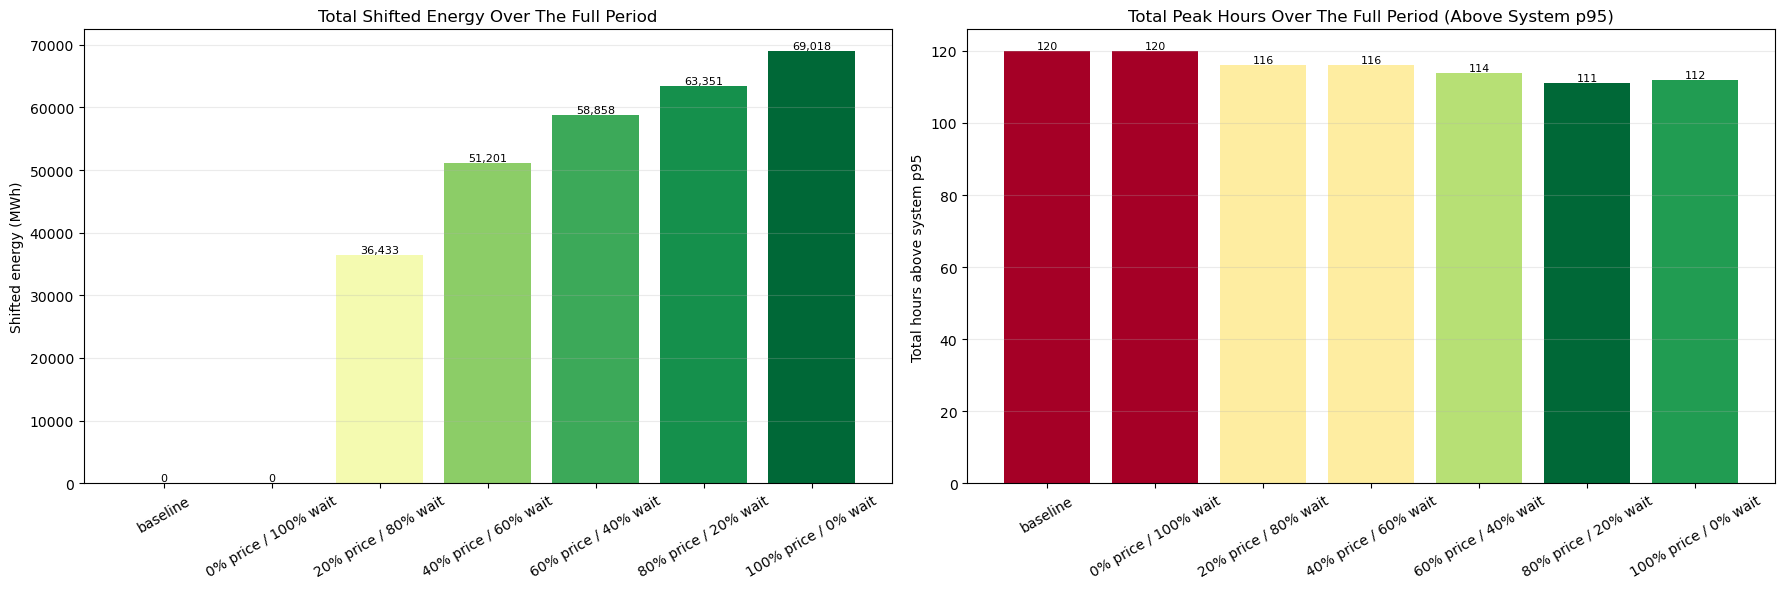

In [14]:
plot_df = round1_results_df.copy()

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

energy_colors = make_red_green_colors(plot_df["total_shifted_energy_mwh"], higher_is_better=True)
axes[0].bar(plot_df["config_label"], plot_df["total_shifted_energy_mwh"], color=energy_colors)
axes[0].set_title("Total Shifted Energy Over The Full Period")
axes[0].set_ylabel("Shifted energy (MWh)")
axes[0].grid(axis="y", alpha=0.25)
for idx, value in enumerate(plot_df["total_shifted_energy_mwh"]):
    axes[0].text(idx, value, f"{value:,.0f}", ha="center", va="bottom", fontsize=8)

peak_colors = make_red_green_colors(plot_df["total_shifted_hours_above_p95"], higher_is_better=False)
axes[1].bar(plot_df["config_label"], plot_df["total_shifted_hours_above_p95"], color=peak_colors)
axes[1].set_title("Total Peak Hours Over The Full Period (Above System p95)")
axes[1].set_ylabel("Total hours above system p95")
axes[1].grid(axis="y", alpha=0.25)
for idx, value in enumerate(plot_df["total_shifted_hours_above_p95"]):
    axes[1].text(idx, value, f"{int(value)}", ha="center", va="bottom", fontsize=8)

for ax in axes:
    ax.tick_params(axis="x", rotation=30)

plt.tight_layout()


## Part 2: Max Shiftable Share Simulation

This keeps the score weights fixed at the current default `80% price / 20% wait` and varies only the segment-specific `max_shiftable_share` values.


In [15]:
ROUND2_BASE_WEIGHT_OVERRIDES = {"price": 0.8, "wait": 0.2}
ROUND2_SHIFTABLE_SHARE_GRID = {
    "wet_loads": [0.35, 0.55, 0.75],
    "thermal": [0.15, 0.25, 0.35],
    "ev": [0.65, 0.85, 0.95],
}

round2_aggregate_frames = [pd.DataFrame([baseline_totals])]

for wet_share, thermal_share, ev_share in product(
    ROUND2_SHIFTABLE_SHARE_GRID["wet_loads"],
    ROUND2_SHIFTABLE_SHARE_GRID["thermal"],
    ROUND2_SHIFTABLE_SHARE_GRID["ev"],
):
    config_label = f"wet {wet_share:.2f} | thermal {thermal_share:.2f} | ev {ev_share:.2f}"
    _, aggregate_df = evaluate_config_across_issue_times(
        config_name=f"share_wet_{wet_share:.2f}__thermal_{thermal_share:.2f}__ev_{ev_share:.2f}",
        config_label=config_label,
        issue_times=search_issue_times,
        peak_thresholds=peak_thresholds,
        decision_weight_overrides=ROUND2_BASE_WEIGHT_OVERRIDES,
        segment_overrides={
            "wet_loads": {"max_shiftable_share": float(wet_share)},
            "thermal": {"max_shiftable_share": float(thermal_share)},
            "ev": {"max_shiftable_share": float(ev_share)},
        },
    )
    round2_aggregate_frames.append(aggregate_df)

round2_results_df = pd.concat(round2_aggregate_frames, ignore_index=True)
display(
    round2_results_df[
        [
            "config_label",
            "total_shifted_hours_above_p95",
            "total_shifted_hours_above_p99",
            "total_shifted_energy_mwh",
            "total_realized_household_savings_eur",
        ]
    ].head(10)
)


,config_label,total_shifted_hours_above_p95,total_shifted_hours_above_p99,total_shifted_energy_mwh,total_realized_household_savings_eur
0,baseline,120,16,0.000000,0.000000e+00
1,wet 0.35 | thermal 0.15 | ev 0.65,111,15,63350.762866,1.483321e+06
2,wet 0.35 | thermal 0.15 | ev 0.85,110,15,64416.248195,1.524476e+06
3,wet 0.35 | thermal 0.15 | ev 0.95,110,15,64715.122174,1.548757e+06
4,wet 0.35 | thermal 0.25 | ev 0.65,112,15,70356.795117,1.643680e+06
5,wet 0.35 | thermal 0.25 | ev 0.85,111,15,71422.280446,1.684835e+06
6,wet 0.35 | thermal 0.25 | ev 0.95,111,15,71721.154426,1.709115e+06
7,wet 0.35 | thermal 0.35 | ev 0.65,113,15,74579.459983,1.740918e+06
8,wet 0.35 | thermal 0.35 | ev 0.85,112,15,75644.945312,1.782073e+06
9,wet 0.35 | thermal 0.35 | ev 0.95,112,15,75943.819292,1.806354e+06


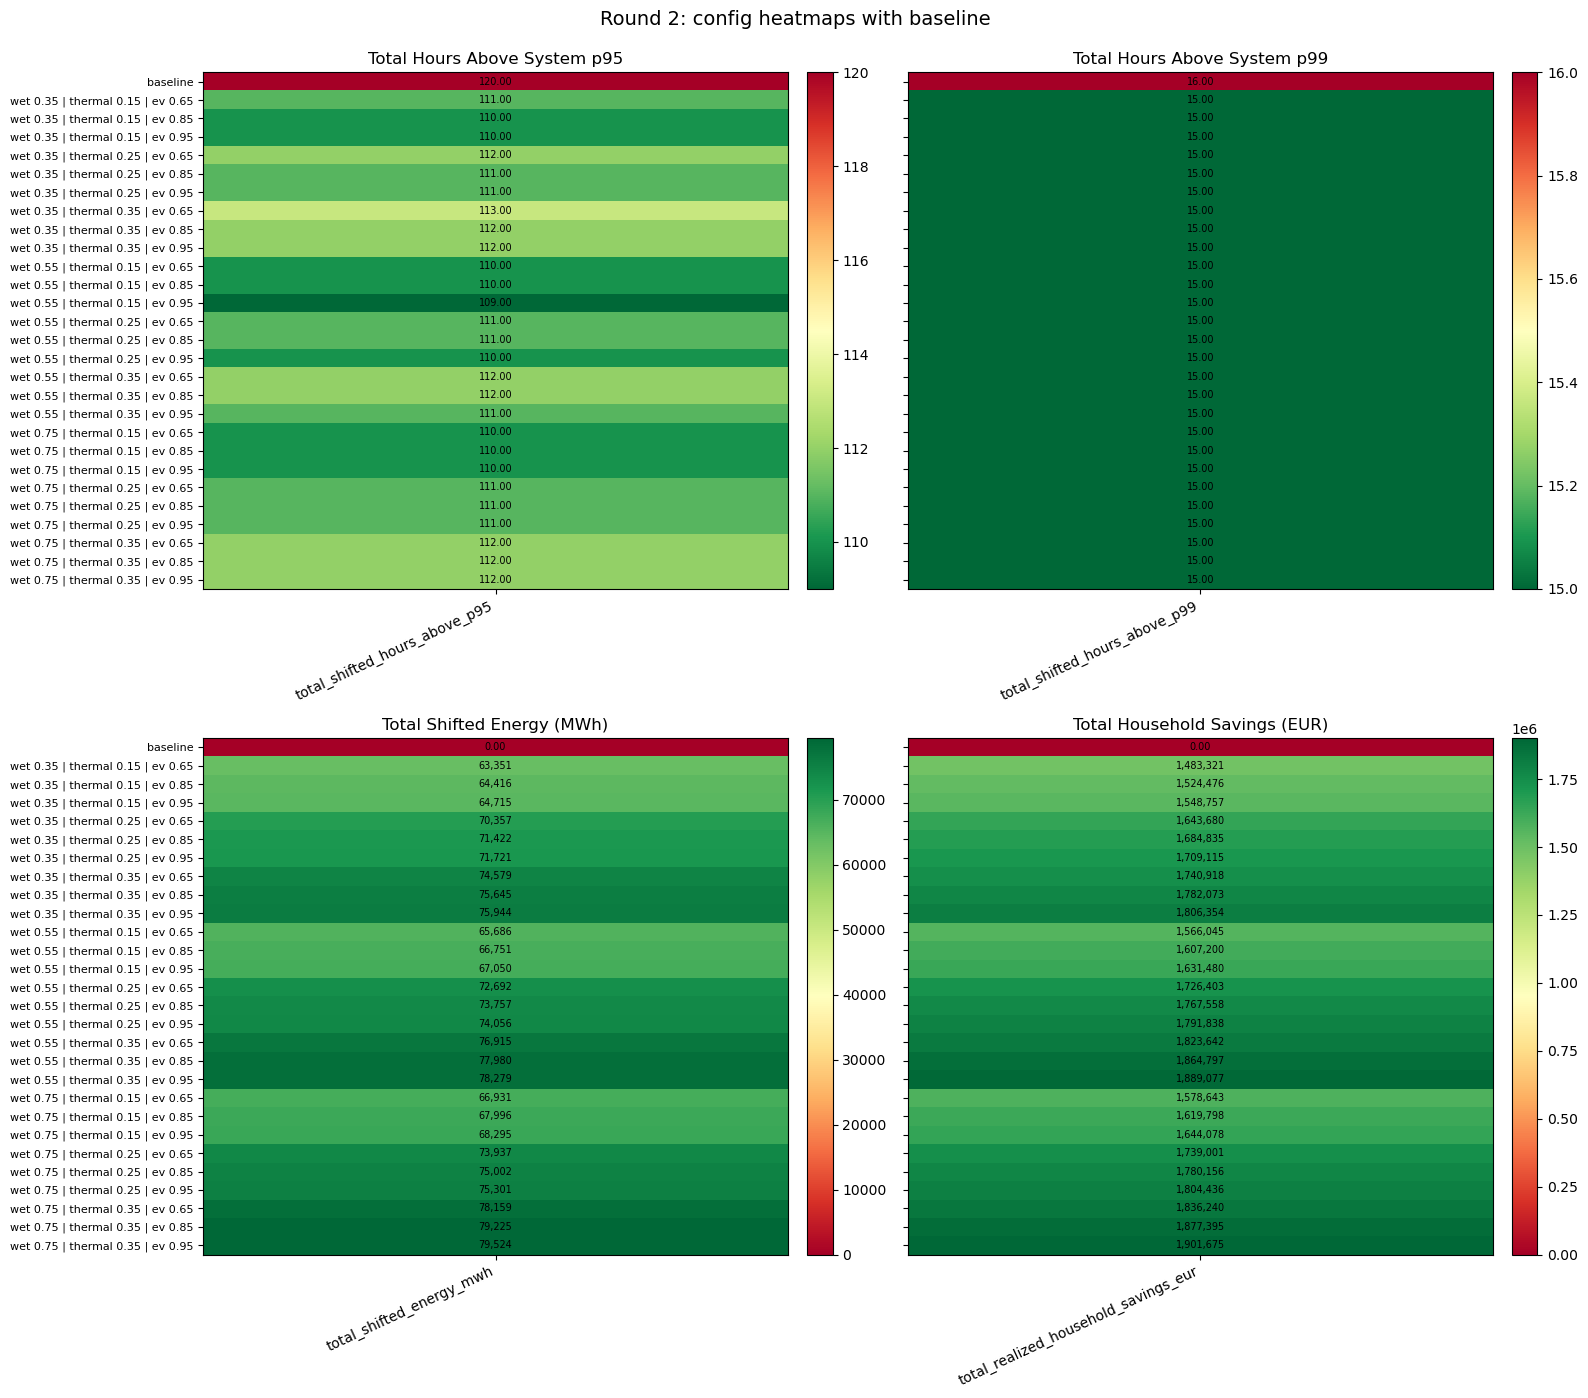

In [16]:
round2_heatmap_df = round2_results_df.sort_values("config_label").reset_index(drop=True)
baseline_row = round2_heatmap_df[round2_heatmap_df["config_name"] == "baseline"]
non_baseline_rows = round2_heatmap_df[round2_heatmap_df["config_name"] != "baseline"]
round2_heatmap_df = pd.concat([baseline_row, non_baseline_rows], ignore_index=True)

panel_specs = [
    ("total_shifted_hours_above_p95", "Total Hours Above System p95", "RdYlGn_r"),
    ("total_shifted_hours_above_p99", "Total Hours Above System p99", "RdYlGn_r"),
    ("total_shifted_energy_mwh", "Total Shifted Energy (MWh)", "RdYlGn"),
    ("total_realized_household_savings_eur", "Total Household Savings (EUR)", "RdYlGn"),
]

fig, axes = plt.subplots(2, 2, figsize=(16, 14), sharey=True)
axes = axes.flatten()

for ax, (metric_col, title, cmap) in zip(axes, panel_specs):
    values = round2_heatmap_df[[metric_col]].to_numpy(dtype=float)
    im = ax.imshow(values, aspect="auto", cmap=cmap, interpolation="nearest")
    ax.set_title(title)
    ax.set_xticks([0])
    ax.set_xticklabels([metric_col], rotation=25, ha="right")
    ax.set_yticks(np.arange(len(round2_heatmap_df)))
    ax.set_yticklabels(round2_heatmap_df["config_label"].tolist(), fontsize=8)

    for row_idx, value in enumerate(round2_heatmap_df[metric_col]):
        text_value = f"{value:,.2f}" if abs(value) < 1000 else f"{value:,.0f}"
        ax.text(0, row_idx, text_value, ha="center", va="center", fontsize=7, color="black")

    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.03)

fig.suptitle("Round 2: config heatmaps with baseline", fontsize=14, y=0.995)
plt.tight_layout()
